# Griddle Exploration
Load the Blue Mountain test domain and build datasets for manual investigation.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # noqa: F401 — activates .rio accessor
import xarray as xr
from unittest.mock import MagicMock


In [2]:
services_dir = Path('../services')
griddle_dir  = services_dir / 'griddle'
lib_dir      = services_dir / 'lib'

sys.path.insert(0, str(services_dir))
sys.path.insert(0, str(griddle_dir))
sys.path.insert(0, str(lib_dir))

In [3]:
from lib.config import DEPLOYMENT_ENV
from lib.config import TABLES_BUCKET
DEPLOYMENT_ENV

'local'

In [4]:
DOMAIN_FILE = lib_dir / 'tests/shared_data/domains/blue_mtn.json'

CRS  : EPSG:32611
Bounds: [ 720227.93988029 5189763.32399947  721533.6406826  5190645.04851605]


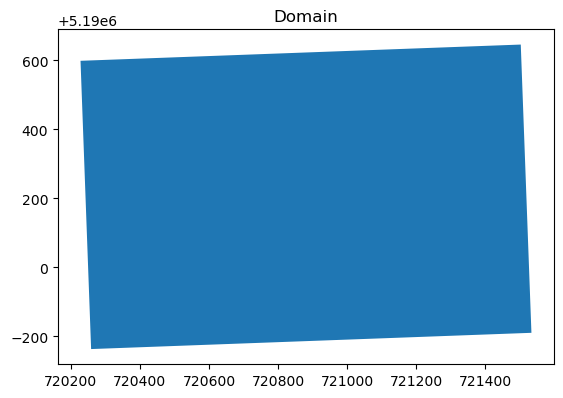

In [5]:
# --- Domain ---------------------------------------------------------------
with open(DOMAIN_FILE) as f:
    domain = json.load(f)

crs = domain["crs"]["properties"]["name"]
roi = gpd.GeoDataFrame.from_features(domain["features"], crs=crs)

print("CRS  :", roi.crs)
print("Bounds:", roi.total_bounds)
roi.plot()
plt.title("Domain")
plt.show()

In [7]:
# --- Handlers (import what you need) --------------------------------------
from griddle.handlers.landfire import fetch_fbfm40, fetch_fccs, fetch_canopy_landfire
from griddle.handlers.landfire import fetch_topography as fetch_topography_lf
from griddle.handlers.pim import fetch_treemap
from griddle.handlers.uniform import create_uniform_grid
from griddle.handlers.threedep import fetch_topography as fetch_topography_3dep
from griddle.handlers.chm import fetch_meta_chm, fetch_naip_chm
#from griddle.handlers.layerset import fetch_layerset
_DEFAULT_NATIVE_RESOLUTION_M = 2.0

#from services.griddle.griddle.summarize import summarize_dataset

In [8]:
progress = MagicMock()
datasets = {}

datasets["fbfm40"] = fetch_fbfm40(roi=roi, version="2024", extent_buffer_cells=8)
datasets["fccs"] = fetch_fccs(roi=roi, version="2023", extent_buffer_cells=8)
datasets["topography_lf"] = fetch_topography_lf(roi=roi, version="2020", bands=["elevation", "slope", "aspect"], progress=progress, extent_buffer_cells=8)
datasets["canopy_lf"] = fetch_canopy_landfire(roi=roi, version="2024", bands=["chm", "cbd", "cbh", "cc"], progress=progress, extent_buffer_cells=8)
datasets["treemap"] = fetch_treemap(roi=roi, version="2022", bands=["tm_id", "plt_cn"], progress=progress, extent_buffer_cells=8)
datasets["uniform"] = create_uniform_grid(domain_gdf=roi, bands=[{"key": "fuel_moisture", "value": 0.1}], resolution=30.0, progress=progress)
datasets["topography_3dep"], tile_metadata_3dep = fetch_topography_3dep(roi=roi, resolution=10, bands=["elevation", "slope", "aspect"], progress=progress, extent_buffer_cells=8)
datasets["meta_chm"], tile_metadata_meta = fetch_meta_chm(roi=roi, version="1", progress=progress, extent_buffer_cells=8)
datasets["naip_chm"], tile_metadata_naip = fetch_naip_chm(roi=roi, progress=progress, extent_buffer_cells=8)

In [30]:
datasets["uniform"] = create_uniform_grid(domain_gdf=roi, bands=[{"key": "fuel_moisture", "value": 1}], resolution=30.0, progress=progress)


In [9]:
for name, ds in datasets.items():
    print(f"\n--- {name} ---")
    for var in ds.data_vars:
        da = ds[var]
        print(f"  {var}: dtype={da.dtype}, rio.nodata={da.rio.nodata}, _FillValue={da.attrs.get('_FillValue')}")


--- fbfm40 ---
  fbfm: dtype=int16, rio.nodata=32767, _FillValue=32767

--- fccs ---
  fccs: dtype=int32, rio.nodata=2147483647, _FillValue=2147483647

--- topography_lf ---
  elevation: dtype=int16, rio.nodata=32767, _FillValue=32767
  slope: dtype=int16, rio.nodata=32767, _FillValue=32767
  aspect: dtype=int16, rio.nodata=32767, _FillValue=32767

--- canopy_lf ---
  chm: dtype=float32, rio.nodata=nan, _FillValue=None
  cbd: dtype=float32, rio.nodata=nan, _FillValue=None
  cbh: dtype=float32, rio.nodata=nan, _FillValue=None
  cc: dtype=float32, rio.nodata=nan, _FillValue=None

--- treemap ---
  tm_id: dtype=uint32, rio.nodata=4294967295, _FillValue=4294967295
  plt_cn: dtype=int64, rio.nodata=0, _FillValue=0

--- uniform ---
  fuel_moisture: dtype=float32, rio.nodata=nan, _FillValue=nan

--- topography_3dep ---
  elevation: dtype=float32, rio.nodata=-999999.0, _FillValue=-999999.0
  slope: dtype=float32, rio.nodata=-999999.0, _FillValue=-999999.0
  aspect: dtype=float32, rio.nodata=-

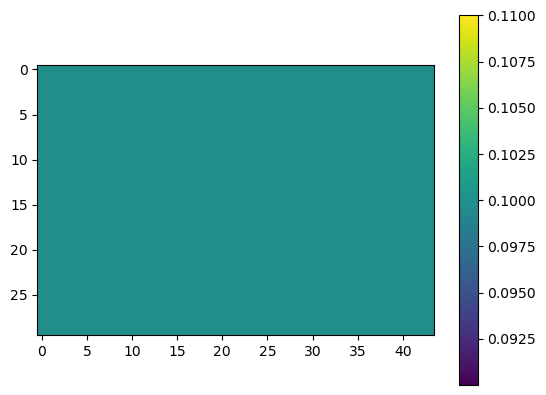

In [16]:
plt.imshow(datasets['uniform']['fuel_moisture'])
plt.colorbar()

In [31]:
from griddle.summarize import summarize_dataset

results = {}

results["fbfm40"] = summarize_dataset(
    datasets["fbfm40"],
    [{"key": "fbfm", "type": "categorical"}]
)

results["fccs"] = summarize_dataset(
    datasets["fccs"],
    [{"key": "fccs", "type": "categorical"}]
)

results["topography_lf"] = summarize_dataset(
    datasets["topography_lf"],
    [
        {"key": "elevation", "type": "continuous"},
        {"key": "slope", "type": "continuous"},
        {"key": "aspect", "type": "continuous"},
    ]
)

results["canopy_lf"] = summarize_dataset(
    datasets["canopy_lf"],
    [
        {"key": "chm", "type": "continuous"},
        {"key": "cbd", "type": "continuous"},
        {"key": "cbh", "type": "continuous"},
        {"key": "cc", "type": "continuous"},
    ]
)

results["treemap"] = summarize_dataset(
    datasets["treemap"],
    [
        {"key": "tm_id", "type": "categorical"},
        {"key": "plt_cn", "type": "categorical"},
    ]
)

results["uniform"] = summarize_dataset(
    datasets["uniform"],
    [{"key": "fuel_moisture", "type": "continuous"}]
)

results["topography_3dep"] = summarize_dataset(
    datasets["topography_3dep"],
    [
        {"key": "elevation", "type": "continuous"},
        {"key": "slope", "type": "continuous"},
        {"key": "aspect", "type": "continuous"},
    ]
)

results["meta_chm"] = summarize_dataset(
    datasets["meta_chm"],
    [{"key": "chm", "type": "continuous"}]
)

results["naip_chm"] = summarize_dataset(
    datasets["naip_chm"],
    [{"key": "chm", "type": "continuous"}]
)

results["layerset"] = summarize_dataset(
    datasets["layerset"],
    [{"key": var, "type": "continuous"} for var in datasets["layerset"].data_vars]
)

for handler, summary in results.items():
    print(f"\n--- {handler} ---")
    for key, s in summary.items():
        print(f"  {key}: {s}")


--- fbfm40 ---
  fbfm: {'type': 'categorical', 'count': 2806, 'nodata_count': 0, 'unique_count': 11}

--- fccs ---
  fccs: {'type': 'categorical', 'count': 2806, 'nodata_count': 0, 'unique_count': 23}

--- topography_lf ---
  elevation: {'type': 'continuous', 'count': 2806, 'nodata_count': 0, 'min': 951.0, 'max': 1225.0, 'mean': 1040.8300071275837, 'std': 62.8333842916301}
  slope: {'type': 'continuous', 'count': 2806, 'nodata_count': 0, 'min': 0.0, 'max': 25.0, 'mean': 9.061297220242338, 'std': 5.128618600754228}
  aspect: {'type': 'continuous', 'count': 2806, 'nodata_count': 0, 'min': -1.0, 'max': 356.0, 'mean': 103.55381325730578, 'std': 103.16282892068632}

--- canopy_lf ---
  chm: {'type': 'continuous', 'count': 2806, 'nodata_count': 0, 'min': 0.0, 'max': 39.0, 'mean': 7.999821804644419, 'std': 8.347481382533251}
  cbd: {'type': 'continuous', 'count': 2806, 'nodata_count': 0, 'min': 0.0, 'max': 0.15000000596046448, 'mean': 0.03241268692820924, 'std': 0.036256422718609814}
  cbh: 

In [17]:
np.unique(datasets["fbfm40"]["fbfm"].values)

array([ 91,  99, 102, 121, 122, 142, 146, 161, 162, 165, 188], dtype=int16)

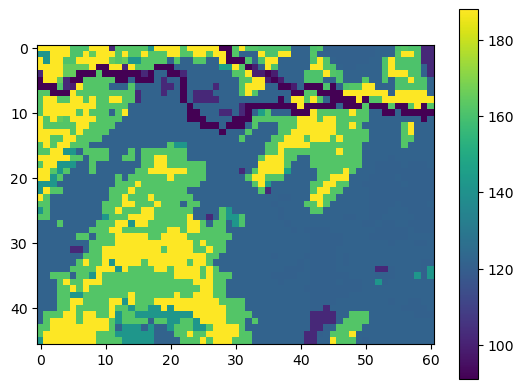

In [18]:
plt.imshow(datasets["fbfm40"]["fbfm"])
plt.colorbar()

In [19]:
print(np.unique(datasets["treemap"]["plt_cn"].values))
print(np.unique(datasets["uniform"]["fuel_moisture"].values))

[    490387913126144 9223372036854775807]
[0.1]


In [20]:
datasets['treemap']['tm_id'].data

array([[      4215,       7378,       4215, ...,       4766, 4294967295,
        4294967295],
       [      4215,       4215,       4215, ...,       4766, 4294967295,
        4294967295],
       [      4215,       7378,       7378, ...,       5892, 4294967295,
        4294967295],
       ...,
       [     10064,       7378,      10065, ..., 4294967295, 4294967295,
        4294967295],
       [     54292,       7378,      10065, ..., 4294967295, 4294967295,
        4294967295],
       [     26377,       7378,      26377, ..., 4294967295, 4294967295,
        4294967295]], shape=(46, 61), dtype=uint32)

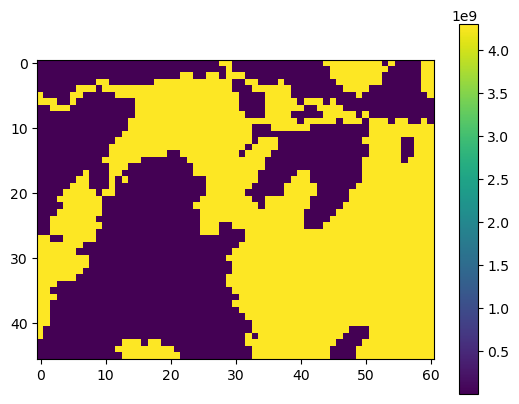

In [33]:
plt.imshow(datasets['treemap']['tm_id'].data)
plt.colorbar()

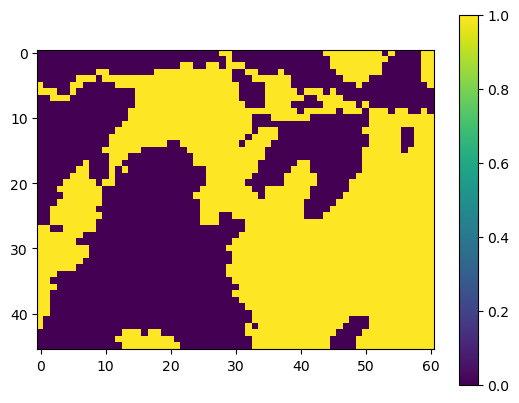

In [21]:
plt.imshow(datasets['treemap']['tm_id'].data==4294967295)
plt.colorbar()

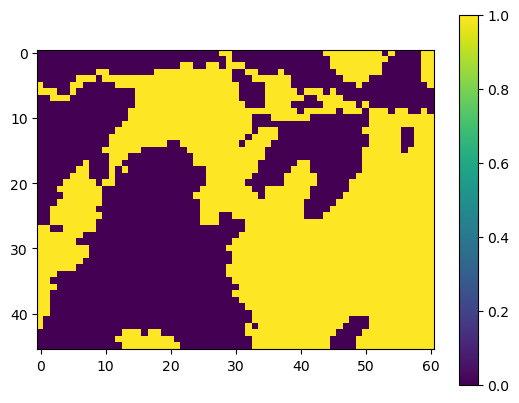

In [23]:
plt.imshow(datasets['treemap']['plt_cn'].data==datasets['treemap']['plt_cn'].rio.nodata)
plt.colorbar()

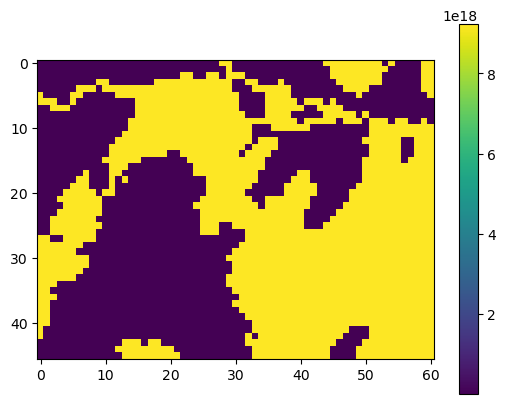

In [32]:
plt.imshow(datasets['treemap']['plt_cn'].data)
plt.colorbar()

In [81]:
version = "2022"
tm_col, cn_col = "TM_ID", "PLT_CN"

table_url = f"gs://{TABLES_BUCKET}/TreeMap{version}_tree_table.parquet"
df = pd.read_parquet(table_url, columns=[tm_col, cn_col])
full_df = pd.read_parquet(table_url)

In [82]:
tm_id_da = datasets['treemap']['tm_id']
tm_id_da

<xarray.DataArray 'tm_id' (y: 46, x: 61)> Size: 11kB
array([[      4215,       7378,       4215, ...,       4766, 4294967295,
        4294967295],
       [      4215,       4215,       4215, ...,       4766, 4294967295,
        4294967295],
       [      4215,       7378,       7378, ...,       5892, 4294967295,
        4294967295],
       ...,
       [     10064,       7378,      10065, ..., 4294967295, 4294967295,
        4294967295],
       [     54292,       7378,      10065, ..., 4294967295, 4294967295,
        4294967295],
       [     26377,       7378,      26377, ..., 4294967295, 4294967295,
        4294967295]], shape=(46, 61), dtype=uint32)
Coordinates:
  * y            (y) float64 368B 5.191e+06 5.191e+06 ... 5.19e+06 5.19e+06
  * x            (x) float64 488B 7.2e+05 7.2e+05 ... 7.217e+05 7.218e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MINIMUM:  1
    STATISTICS_MAXIMUM:  70035
    STATISTICS_MEAN:     -9999
    STATISTICS_STDDEV:   -9999
    scale_factor:        1.0
    add_offset:          0.0
    long_name:           TM_ID
    _FillValue:          4294967295

In [83]:
mapping_df = df[[tm_col, cn_col]].drop_duplicates(subset=[tm_col])
mapping_df

,TM_ID,PLT_CN
0,1,2232677010690
11,2,2238927010690
41,3,2252565010690
56,4,2252827010690
76,5,2255590010690
...,...,...
2388242,70031,44541093020004
2388251,70032,48202722010497
2388265,70033,216960934020004
2388277,70034,412221886489998


In [84]:
tm_ids = mapping_df[tm_col].values
tm_ids

array([    1,     2,     3, ..., 70033, 70034, 70035], shape=(65043,))

In [85]:
plt_cns = mapping_df[cn_col].values
plt_cns

array([  2232677010690,   2238927010690,   2252565010690, ...,
       216960934020004, 412221886489998, 490387913126144], shape=(65043,))

In [86]:
max_tm_id = int(tm_ids.max())
max_tm_id

70035

In [87]:
nodata_value = np.iinfo(np.int64).min
lookup = np.full(max_tm_id + 1, nodata_value, dtype=np.int64)
lookup

array([-9223372036854775808, -9223372036854775808, -9223372036854775808,
       ..., -9223372036854775808, -9223372036854775808,
       -9223372036854775808], shape=(70036,))

In [88]:
lookup[tm_ids] = plt_cns
lookup

array([-9223372036854775808,        2232677010690,        2238927010690,
       ...,      216960934020004,      412221886489998,
            490387913126144], shape=(70036,))

In [89]:
raw = tm_id_da.values.astype(np.int64)
raw

array([[      4215,       7378,       4215, ...,       4766, 4294967295,
        4294967295],
       [      4215,       4215,       4215, ...,       4766, 4294967295,
        4294967295],
       [      4215,       7378,       7378, ...,       5892, 4294967295,
        4294967295],
       ...,
       [     10064,       7378,      10065, ..., 4294967295, 4294967295,
        4294967295],
       [     54292,       7378,      10065, ..., 4294967295, 4294967295,
        4294967295],
       [     26377,       7378,      26377, ..., 4294967295, 4294967295,
        4294967295]], shape=(46, 61))

In [90]:
raw_clipped = np.clip(raw, 0, max_tm_id)
raw_clipped

array([[ 4215,  7378,  4215, ...,  4766, 70035, 70035],
       [ 4215,  4215,  4215, ...,  4766, 70035, 70035],
       [ 4215,  7378,  7378, ...,  5892, 70035, 70035],
       ...,
       [10064,  7378, 10065, ..., 70035, 70035, 70035],
       [54292,  7378, 10065, ..., 70035, 70035, 70035],
       [26377,  7378, 26377, ..., 70035, 70035, 70035]], shape=(46, 61))

In [91]:
plt_cn_values = lookup[raw_clipped]
plt_cn_values

array([[ 30764171020004,  40220542010497,  30764171020004, ...,
         31454968010690, 490387913126144, 490387913126144],
       [ 30764171020004,  30764171020004,  30764171020004, ...,
         31454968010690, 490387913126144, 490387913126144],
       [ 30764171020004,  40220542010497,  40220542010497, ...,
         37274399010690, 490387913126144, 490387913126144],
       ...,
       [ 40394790010690,  40220542010497,  40394801010690, ...,
        490387913126144, 490387913126144, 490387913126144],
       [484819577489998,  40220542010497,  40394801010690, ...,
        490387913126144, 490387913126144, 490387913126144],
       [188765736020004,  40220542010497, 188765736020004, ...,
        490387913126144, 490387913126144, 490387913126144]],
      shape=(46, 61))

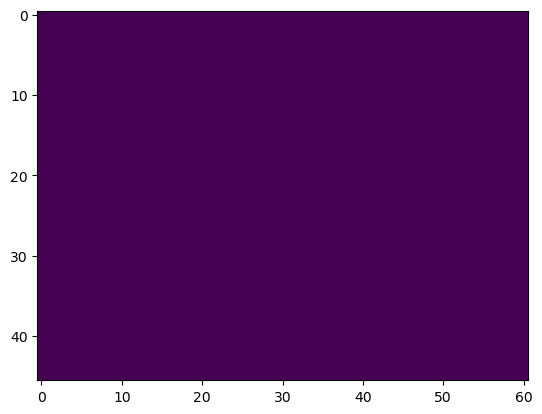

In [92]:
plt.imshow(raw == 0)

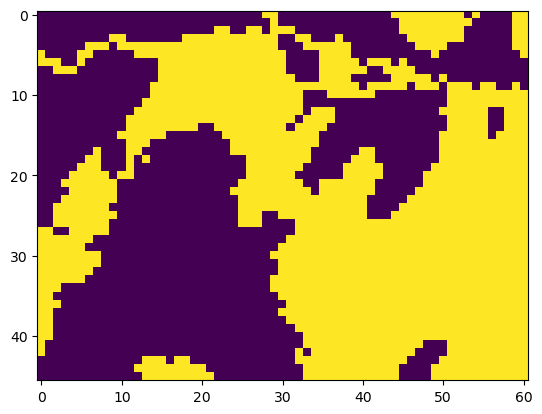

In [93]:
plt.imshow(raw>max_tm_id)

In [94]:
plt_cn_values[raw < 0] = nodata_value
plt_cn_values[raw > max_tm_id] = nodata_value

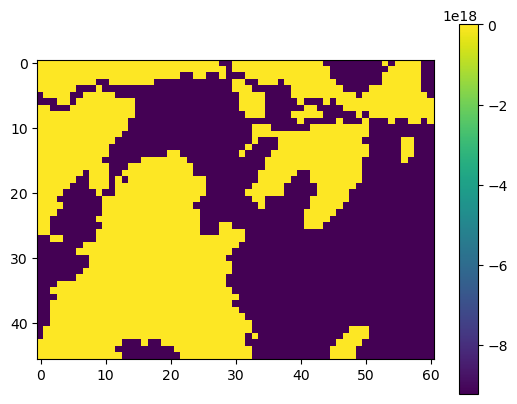

In [95]:
plt.imshow(plt_cn_values)
plt.colorbar()

In [96]:
for i in df.TM_ID.unique():
    print(i,end=', ')

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 174, 175, 176, 177, 178, 179, 181, 182, 183, 184, 185, 186, 187, 189, 190, 191, 192, 193, 194, 195, 196, 197, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227

In [97]:
np.all(df.TM_ID.unique, np.arange(1,

_IncompleteInputError: incomplete input (203412475.py, line 1)

In [78]:
np.arange(1,len(df.TM_ID.unique()))

array([    1,     2,     3, ..., 65040, 65041, 65042], shape=(65042,))

In [51]:
# from api.resources.grids.schema.py
fbfm_grid = {
    "id": "test-fbfm-grid",
    "domain_id": "test-domain",
    "status": "running",
    "source": {
        "name": "landfire",
        "product": "fbfm40",
        "version": "2024",
        "extent_buffer_cells": 8,
        "alignment": {"target": "domain"},
    },
    "bands": [
        {"key": "fbfm", "type": "categorical", "unit": None, "index": 0}
    ],
    "modifications": [],
    "tags": [],
}

In [52]:
fbfm_grid['bands']

[{'key': 'fbfm', 'type': 'categorical', 'unit': None, 'index': 0}]

In [53]:
ds_fbfm.fbfm.rio.nodata

np.int16(32767)

In [54]:
topo_grid = {
    "id": "test-topo-grid",
    "domain_id": "test-domain",
    "status": "running",
    "source": {
        "name": "landfire",
        "product": "topogrphy",
        "version": "2020",
        "extent_buffer_cells": 8,
        "alignment": {"target": "domain"},
    },
    "bands": [
        {"key": "elevation", "type": "continuous", "unit": "m",       "index": 0},
        {"key": "slope",     "type": "continuous", "unit": "degrees",  "index": 1},
        {"key": "aspect",    "type": "continuous", "unit": "degrees",  "index": 2},
    ],
    "modifications": [],
    "tags": [],
}

In [55]:
for band in topo_grid['bands']:
    print(band['key'])
    print(band['type'])

elevation
continuous
slope
continuous
aspect
continuous


In [56]:
elev_da = ds_topo['elevation']
elev_da

<xarray.DataArray 'elevation' (y: 34, x: 34)> Size: 2kB
array([[2776, 2774, 2771, ..., 2640, 2633, 2624],
       [2770, 2766, 2762, ..., 2629, 2621, 2613],
       [2760, 2755, 2750, ..., 2618, 2611, 2603],
       ...,
       [2540, 2529, 2519, ..., 2474, 2483, 2493],
       [2534, 2524, 2515, ..., 2485, 2496, 2505],
       [2526, 2517, 2509, ..., 2496, 2506, 2515]],
      shape=(34, 34), dtype=int16)
Coordinates:
  * y            (y) float64 272B 4.721e+06 4.721e+06 ... 4.72e+06 4.72e+06
  * x            (x) float64 272B 5.226e+05 5.226e+05 ... 5.235e+05 5.235e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:           Area
    RepresentationType:      ATHEMATIC
    STATISTICS_COVARIANCES:  27573480.57289442
    STATISTICS_MAXIMUM:      4413
    STATISTICS_MEAN:         -3371.2945941746
    STATISTICS_MINIMUM:      -9999
    STATISTICS_SKIPFACTORX:  1
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       5251.0456647124
    scale_factor:            1.0
    add_offset:              0.0
    _FillValue:              32767

In [58]:
isinstance(elev_da.data, dsa.Array)

False

In [59]:
arr = np.asarray(elev_da)
arr

array([[2776, 2774, 2771, ..., 2640, 2633, 2624],
       [2770, 2766, 2762, ..., 2629, 2621, 2613],
       [2760, 2755, 2750, ..., 2618, 2611, 2603],
       ...,
       [2540, 2529, 2519, ..., 2474, 2483, 2493],
       [2534, 2524, 2515, ..., 2485, 2496, 2505],
       [2526, 2517, 2509, ..., 2496, 2506, 2515]],
      shape=(34, 34), dtype=int16)

In [63]:
elev_da.rio.nodata

np.int16(32767)

In [69]:
np.isnan(ds_topo.slope.rio.nodata)

np.False_

In [67]:
ds_treemap = fetch_treemap(roi, 2022, ['tm_id','plt_cn'],progress)

In [68]:
ds_treemap

<xarray.Dataset> Size: 4kB
Dimensions:      (x: 18, y: 18)
Coordinates:
  * x            (x) float64 144B 5.228e+05 5.228e+05 ... 5.233e+05 5.233e+05
  * y            (y) float64 144B 4.721e+06 4.721e+06 ... 4.72e+06 4.72e+06
    spatial_ref  int64 8B 0
Data variables:
    tm_id        (y, x) uint32 1kB 12486 12486 4294967295 ... 8926 8926 826
    plt_cn       (y, x) int64 3kB 40422841010690 ... 2831840010690

In [ ]:
progress = MagicMock()

datasets = {
    "fbfm40": (
        fetch_fbfm40(roi=roi, version="2024", extent_buffer_cells=8),
        [{"key": "fbfm", "type": "categorical"}]
    ),
    "topography": (
        fetch_topography(roi=roi, version="2020", bands=["elevation", "slope", "aspect"], progress=progress, extent_buffer_cells=8),
        [{"key": "elevation", "type": "continuous"}, {"key": "slope", "type": "continuous"}, {"key": "aspect", "type": "continuous"}]
    ),
}

for handler_name, (ds, bands) in datasets.items():
    print(f"\n--- {handler_name} ---")
    for band in bands:
        key = band["key"]
        da = ds[key]
        print(f"  {key}: dtype={da.dtype}, rio.nodata={da.rio.nodata}, _FillValue={da.attrs.get('_FillValue')}")

In [91]:
da = xr.DataArray(
    np.ones((10, 10), dtype=np.int16),
    dims=["y", "x"],
)
da = da.rio.write_crs("EPSG:32611")
da = da.rio.write_transform()

resampled = da.rio.reproject("EPSG:4326")
print(resampled.rio.nodata)
print(np.unique(resampled.values))

-32768
[1]


In [90]:
da.rio.nodata == None

True